In [61]:
import numpy as np
import matplotlib.pyplot as plt

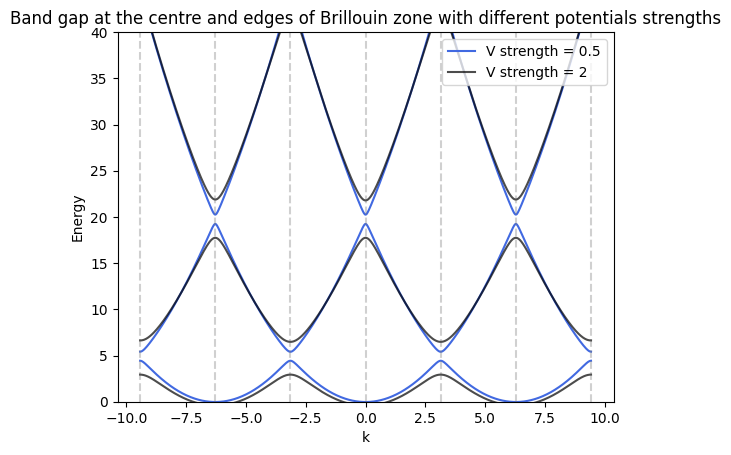

Strength determines the band gap size. Higher the strength, larger the band gap.


In [66]:

#Band gap at the edges of Brillouin zone (k=-3*pi/a to 3*pi/a)

def band(V_G,color,label_name,a,alp):
    G  = 2 * np.pi / a
    E=[]
    # K-space grid
    k_vec = np.linspace(-3 * np.pi / a, 3 * np.pi / a, 1000)

    g_values = [-2*G, -G, 0, G, 2*G]
    num_bands = len(g_values) 

    for k in k_vec:
        # NxN Hamiltonian matrix
        H = np.zeros((num_bands, num_bands), dtype=complex)
        for i in range(num_bands):
            for j in range(num_bands):
                if i == j:
                    # Diagonal elements: Kinetic energy (k - Gi)^2``
                    H[i, j] =  0.5*((k - g_values[i])**2) # in natural units
                else:
                    # V_G's are taken to be the same for all adjacent zones for simplicity
                    H[i, j] = V_G
                
        # Solve for all eigenvalues at this k
        evals = np.linalg.eigvalsh(H)
        E.append(evals)
    energies = np.array(E)

    # Plots
    for i in range(num_bands):
            if i == 0:
                current_label = label_name
            else:
                current_label = "_nolegend_"

 
            plt.plot(k_vec, energies[:, i],color=color,label=current_label,alpha =alp)

    for n in [-3, -2, -1,0, 1, 2, 3]:
        plt.axvline(n * np.pi / a,color='grey', linestyle='--',alpha=0.2)

# Strength comparison of V = 0.5 and V = 2
band(0.5,color="royalblue",label_name="V strength = 0.5",a=1,alp=1)
band(2,color="black",label_name="V strength = 2",a=1,alp=0.7)

plt.title("Band gap at the centre and edges of Brillouin zone with different potentials strengths")
plt.xlabel("k")
plt.ylabel("Energy")
plt.ylim(0, 40) 
plt.legend()
plt.show()
print('Strength determines the band gap size. Higher the strength, larger the band gap.')
